# 📊 Time Series Forecasting – Walmart Sales

## 🎯 Problem Statement
The goal of this project is to predict future Walmart sales using historical data.

## 📂 Dataset Description
The dataset contains weekly sales data from Walmart stores including:
- Store and department information
- Weekly sales
- External factors like temperature, fuel price, and holidays

In [15]:
import pandas as pd
import matplotlib.pyplot as plt

In [16]:
%matplotlib inline

## 📥 Data Loading
In this step, we load the dataset into the notebook.

In [17]:
train = pd.read_csv("dataset/walmart.csv/train.csv")
features = pd.read_csv("dataset/walmart.csv/features.csv")
stores = pd.read_csv("dataset/walmart.csv/stores.csv")
test = pd.read_csv("dataset/walmart.csv/test.csv")


In [18]:
print(train.head())
print(features.head())
print(stores.head())
print(test.head())

   Store  Dept        Date  Weekly_Sales  IsHoliday
0      1     1  2010-02-05      24924.50      False
1      1     1  2010-02-12      46039.49       True
2      1     1  2010-02-19      41595.55      False
3      1     1  2010-02-26      19403.54      False
4      1     1  2010-03-05      21827.90      False
   Store        Date  Temperature  Fuel_Price  MarkDown1  MarkDown2  \
0      1  2010-02-05        42.31       2.572        NaN        NaN   
1      1  2010-02-12        38.51       2.548        NaN        NaN   
2      1  2010-02-19        39.93       2.514        NaN        NaN   
3      1  2010-02-26        46.63       2.561        NaN        NaN   
4      1  2010-03-05        46.50       2.625        NaN        NaN   

   MarkDown3  MarkDown4  MarkDown5         CPI  Unemployment  IsHoliday  
0        NaN        NaN        NaN  211.096358         8.106      False  
1        NaN        NaN        NaN  211.242170         8.106       True  
2        NaN        NaN        NaN  211

In [28]:
df = train.merge(features, on=['Store','Date'], how='left')
df = df.merge(stores, on='Store', how='left')

In [20]:
print(df.columns)

Index(['Store', 'Dept', 'Date', 'Weekly_Sales', 'IsHoliday_x', 'Temperature',
       'Fuel_Price', 'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4',
       'MarkDown5', 'CPI', 'Unemployment', 'IsHoliday_y', 'Type', 'Size'],
      dtype='object')


In [21]:
print(df.head())
print(df.columns)
print(df.info())

   Store  Dept        Date  Weekly_Sales  IsHoliday_x  Temperature  \
0      1     1  2010-02-05      24924.50        False        42.31   
1      1     1  2010-02-12      46039.49         True        38.51   
2      1     1  2010-02-19      41595.55        False        39.93   
3      1     1  2010-02-26      19403.54        False        46.63   
4      1     1  2010-03-05      21827.90        False        46.50   

   Fuel_Price  MarkDown1  MarkDown2  MarkDown3  MarkDown4  MarkDown5  \
0       2.572        NaN        NaN        NaN        NaN        NaN   
1       2.548        NaN        NaN        NaN        NaN        NaN   
2       2.514        NaN        NaN        NaN        NaN        NaN   
3       2.561        NaN        NaN        NaN        NaN        NaN   
4       2.625        NaN        NaN        NaN        NaN        NaN   

          CPI  Unemployment  IsHoliday_y Type    Size  
0  211.096358         8.106        False    A  151315  
1  211.242170         8.106       

## 🧹 Data Cleaning
We clean the dataset by:
- Converting date to proper format
- Handling missing values
- Sorting data for time series analysis

In [22]:
df['Date'] = pd.to_datetime(df['Date'])

df = df.sort_values('Date')

df.fillna(0, inplace=True)

df.set_index('Date', inplace=True)

## 📊 Data Aggregation
We aggregate sales across all stores to create a time series dataset.

In [23]:
df_sales = df.groupby('Date')['Weekly_Sales'].sum()
df_sales.index = pd.to_datetime(df_sales.index)

df_sales.head()

Date
2010-02-05    49750740.50
2010-02-12    48336677.63
2010-02-19    48276993.78
2010-02-26    43968571.13
2010-03-05    46871470.30
Name: Weekly_Sales, dtype: float64

## 📈 Data Visualization
We visualize sales over time to identify trends and patterns.

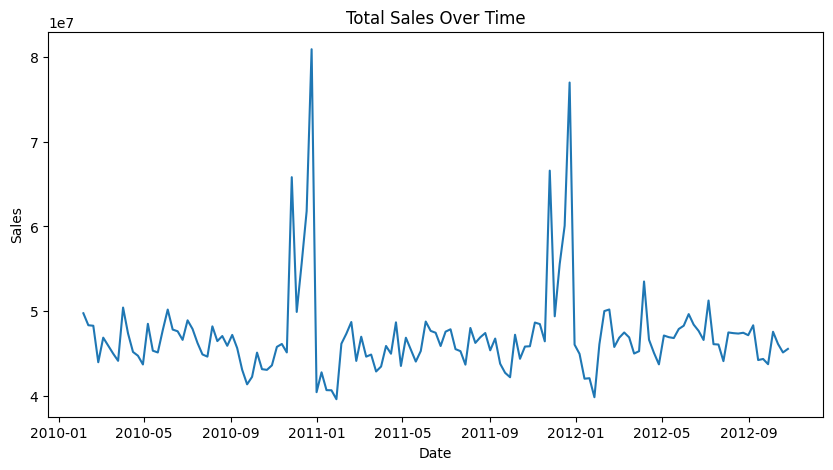

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(df_sales)
plt.title("Total Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.show()

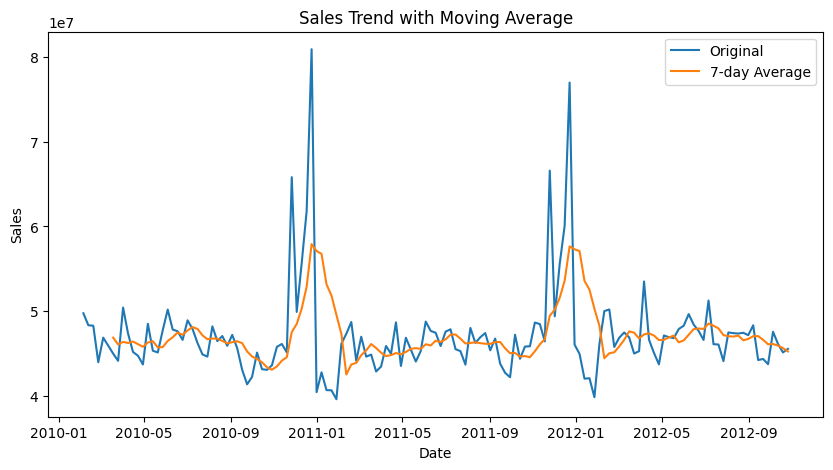

In [25]:
rolling_mean = df_sales.rolling(window=7).mean()

plt.figure(figsize=(10,5))
plt.plot(df_sales, label='Original')
plt.plot(rolling_mean, label='7-day Average')
plt.legend()
plt.title("Sales Trend with Moving Average")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.show()

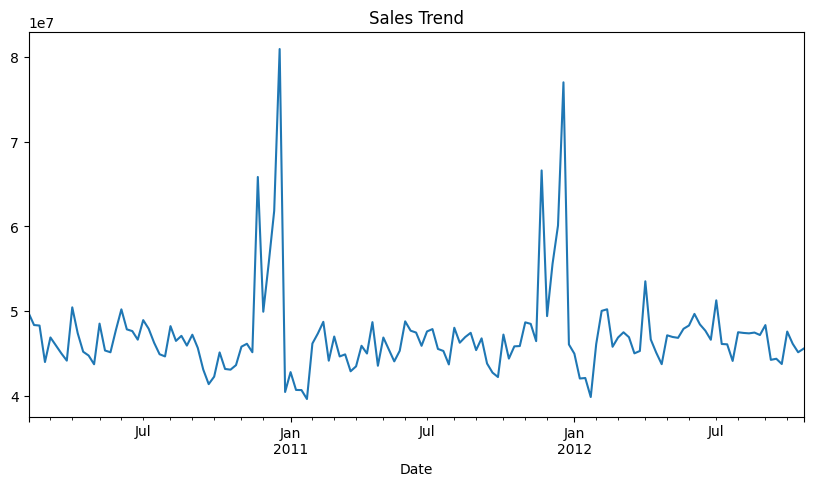

In [26]:
df_sales.plot(figsize=(10,5), title="Sales Trend")
plt.show()

## 📊 Model Evaluation
The model was evaluated using RMSE to measure prediction accuracy.
Lower RMSE indicates better performance.

In [29]:
print(df.columns)

Index(['Store', 'Dept', 'Date', 'Weekly_Sales', 'IsHoliday_x', 'Temperature',
       'Fuel_Price', 'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4',
       'MarkDown5', 'CPI', 'Unemployment', 'IsHoliday_y', 'Type', 'Size'],
      dtype='object')


In [30]:
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date')

df.fillna(0, inplace=True)
df.set_index('Date', inplace=True)

df_sales = df.groupby('Date')['Weekly_Sales'].sum()

df_sales = df_sales.asfreq('W-FRI')
df_sales = df_sales.ffill()

df_sales.head()

Date
2010-02-05    49750740.50
2010-02-12    48336677.63
2010-02-19    48276993.78
2010-02-26    43968571.13
2010-03-05    46871470.30
Freq: W-FRI, Name: Weekly_Sales, dtype: float64

In [31]:
train_data = df_sales[:-30]
test_data = df_sales[-30:]

## 🤖 ARIMA Model

ARIMA (AutoRegressive Integrated Moving Average) is used as a baseline model for forecasting.

- Captures trend and patterns in time series data  
- Suitable for short-term forecasting  

In [32]:
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(train_data, order=(5,1,0))
model_fit = model.fit()

In [33]:
predictions = model_fit.forecast(steps=30)

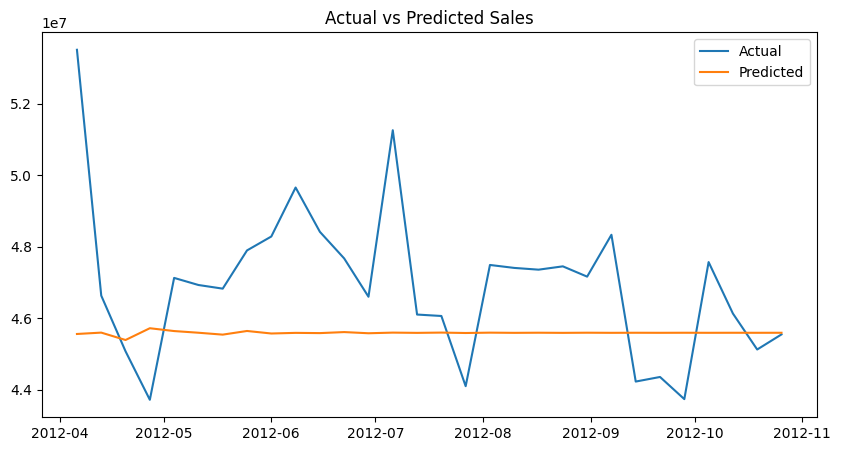

In [34]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(test_data.index, test_data.values, label='Actual')
plt.plot(test_data.index, predictions, label='Predicted')

plt.legend()
plt.title("Actual vs Predicted Sales")
plt.show()

## 📊 Model Evaluation

The model is evaluated using RMSE (Root Mean Squared Error).

- RMSE measures the difference between actual and predicted values  
- Lower RMSE indicates better model performance  

- RMSE Value: 2487022  

In [35]:
from sklearn.metrics import mean_squared_error
import numpy as np

rmse = np.sqrt(mean_squared_error(test_data, predictions))
print("RMSE:", rmse)

RMSE: 2487022.170602841


## 🤖 Prophet Model

Facebook Prophet is an advanced time series forecasting model.

- Automatically captures trend and seasonality  
- Handles missing data effectively  
- Suitable for real-world business forecasting  

In [36]:
!pip install prophet


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [37]:
df_prophet = df_sales.reset_index()
df_prophet.columns = ['ds', 'y']

df_prophet.head()

,ds,y
0,2010-02-05,49750740.50
1,2010-02-12,48336677.63
2,2010-02-19,48276993.78
3,2010-02-26,43968571.13
4,2010-03-05,46871470.30


In [38]:
from prophet import Prophet

model = Prophet()
model.fit(df_prophet)

C:\Users\Nandini Gajendra\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.
21:39:39 - cmdstanpy - INFO - Chain [1] start processing
21:39:39 - cmdstanpy - INFO - Chain [1] done processing


## 📊 Final Forecast Visualization

The final graph compares actual sales with predicted values from the forecasting model.  
This helps in understanding how well the model performs.

In [39]:
future = model.make_future_dataframe(periods=30)

In [40]:
forecast = model.predict(future)

forecast.head()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2010-02-05,4.707966e+07,4.313492e+07,5.192198e+07,4.707966e+07,4.707966e+07,7.041723e+05,7.041723e+05,7.041723e+05,7.041723e+05,7.041723e+05,7.041723e+05,0.0,0.0,0.0,4.778383e+07
1,2010-02-12,4.707920e+07,4.385443e+07,5.298750e+07,4.707920e+07,4.707920e+07,1.414599e+06,1.414599e+06,1.414599e+06,1.414599e+06,1.414599e+06,1.414599e+06,0.0,0.0,0.0,4.849380e+07
2,2010-02-19,4.707874e+07,4.259104e+07,5.148511e+07,4.707874e+07,4.707874e+07,3.743269e+04,3.743269e+04,3.743269e+04,3.743269e+04,3.743269e+04,3.743269e+04,0.0,0.0,0.0,4.711617e+07
3,2010-02-26,4.707828e+07,4.157387e+07,5.085772e+07,4.707828e+07,4.707828e+07,-1.175585e+06,-1.175585e+06,-1.175585e+06,-1.175585e+06,-1.175585e+06,-1.175585e+06,0.0,0.0,0.0,4.590269e+07
4,2010-03-05,4.707781e+07,4.110821e+07,4.990990e+07,4.707781e+07,4.707781e+07,-1.450497e+06,-1.450497e+06,-1.450497e+06,-1.450497e+06,-1.450497e+06,-1.450497e+06,0.0,0.0,0.0,4.562732e+07


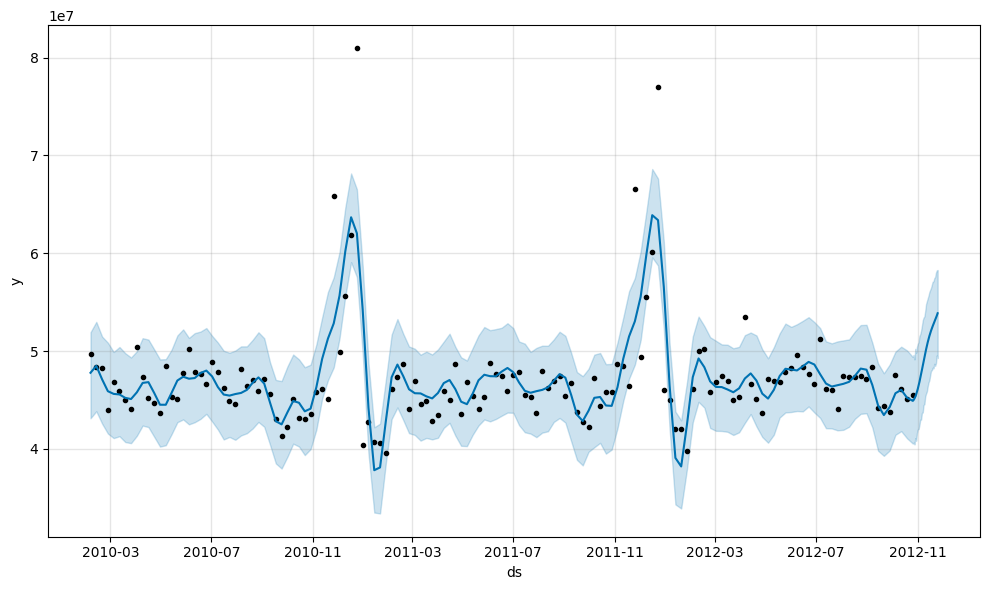

In [41]:
import matplotlib.pyplot as plt

fig = model.plot(forecast)
plt.show()

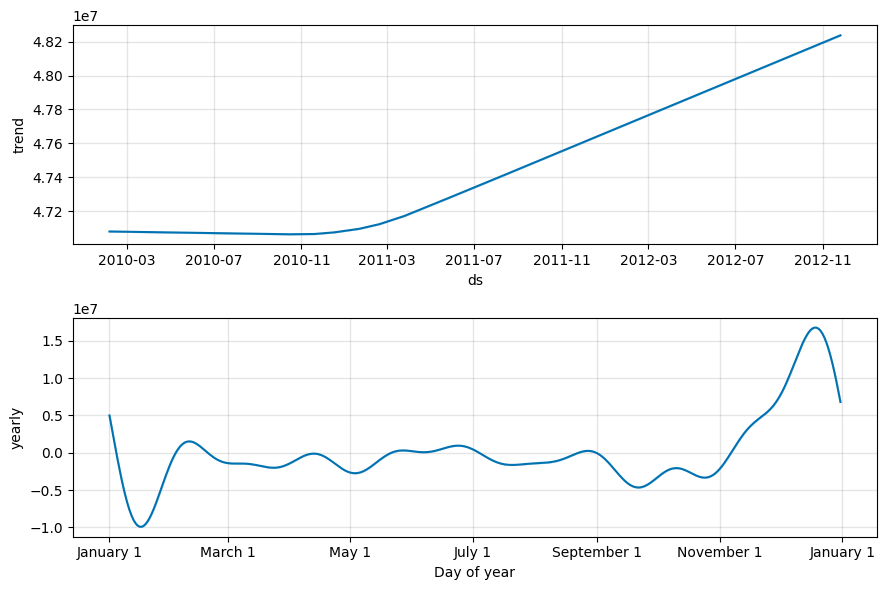

In [42]:
fig2 = model.plot_components(forecast)
plt.show()

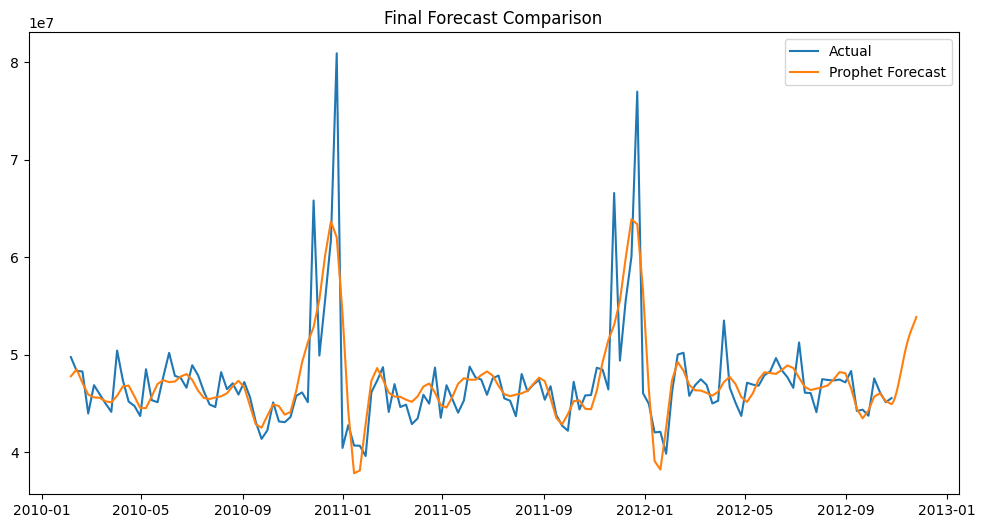

In [43]:
plt.figure(figsize=(12,6))

plt.plot(df_sales.index, df_sales.values, label='Actual')
plt.plot(forecast['ds'], forecast['yhat'], label='Prophet Forecast')

plt.legend()
plt.title("Final Forecast Comparison")
plt.show()

## 📌 Final Insights

- Sales show strong seasonal patterns  
- Weekly trends are clearly visible  
- ARIMA provides baseline forecasting  
- Prophet captures seasonality more effectively  
- Forecast suggests stable future demand  